# ResNet — Fase 2: Exploração Avançada

Parte da análise sobre o melhor modelo encontrado na Fase 1.

| Passo | Técnica | Motivação |
|---|---|---|
| 1 | Learning rate search | Cobre requisito de hyperparameters do enunciado |
| 2 | Fine-tuning gradual | Descongelar backbone progressivamente |
| 3 | LR Scheduler (CosineAnnealing) | Convergência mais estável |
| 4 | Augmentation extra (CutMix) | Regularização para fine-grained classification |
| 5 | Label smoothing | Calibração de confiança em 75 classes |
| 6 | Ablation table | Comparação acumulada de cada técnica |
| 7 | TTA + submission final | Melhorar generalização na inferência |

In [13]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import sys
import copy
import time
import random
import warnings

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

sys.path.append(os.path.abspath("../src"))
from dataset import ButterflyDataset
from transforms import get_transforms

Device: mps


In [14]:
# ── Dataset (igual à fase 1) ───────────────────────────────────────────────────
path = kagglehub.competition_download('aca-butterflies')
competition_dir = path
train_dir = os.path.join(competition_dir, "train")
test_dir  = os.path.join(competition_dir, "test")
train_csv = os.path.join(competition_dir, "train.csv")
test_csv  = os.path.join(competition_dir, "test.csv")

df = pd.read_csv(train_csv)

train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

classes      = sorted(df["label"].unique())
class_to_idx = {cls: i for i, cls in enumerate(classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}
NUM_CLASSES  = len(classes)

train_df["label_idx"] = train_df["label"].map(class_to_idx).astype(int)
val_df["label_idx"]   = val_df["label"].map(class_to_idx).astype(int)

train_transform, val_transform, test_transform = get_transforms()

BATCH_SIZE = 32

train_dataset = ButterflyDataset(train_df, train_dir, transform=train_transform)
val_dataset   = ButterflyDataset(val_df,   train_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {NUM_CLASSES}")

Train: 4159 | Val: 1040 | Classes: 75


In [15]:
# ── Carregar melhor modelo da Fase 1 ──────────────────────────────────────────
# Valores do melhor run da fase 1
BEST_ARCH      = "resnet18"       
BEST_LOSS      = "CrossEntropyLoss"  
BEST_OPTIMIZER = "Adam"           
BEST_LR        = 1e-4             # LR base da fase 1

def build_model(arch, num_classes):
    weights_map = {
        "resnet18": models.ResNet18_Weights.IMAGENET1K_V1,
        "resnet34": models.ResNet34_Weights.IMAGENET1K_V1,
        "resnet50": models.ResNet50_Weights.IMAGENET1K_V2,
    }
    model_fn_map = {
        "resnet18": models.resnet18,
        "resnet34": models.resnet34,
        "resnet50": models.resnet50,
    }
    model = model_fn_map[arch](weights=weights_map[arch])
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def get_criterion(loss_name, label_smoothing=0.0):
    if loss_name == "CrossEntropyLoss":
        return nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    elif loss_name == "MultiMarginLoss":
        return nn.MultiMarginLoss()
    raise ValueError(f"Loss '{loss_name}' não suportada.")


def get_optimizer(opt_name, params, lr, weight_decay=1e-4):
    if opt_name == "Adam":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif opt_name == "RMSprop":
        return optim.RMSprop(params, lr=lr, weight_decay=weight_decay, momentum=0.9)
    raise ValueError(f"Optimizador '{opt_name}' não suportado.")


def train_epoch(model, loader, criterion, optimizer, device, use_cutmix=False, cutmix_alpha=1.0):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_cutmix and np.random.rand() < 0.5:
            images, labels_a, labels_b, lam = cutmix_data(images, labels, cutmix_alpha)
            outputs = model(images)
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
            # Para métricas usa só labels originais (aproximação)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_labels.extend(labels_a.cpu().numpy())
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_labels.extend(labels.cpu().numpy())

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        all_preds.extend(preds)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    epoch_f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1


def val_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    epoch_f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1


def train_model(
    model, criterion, optimizer, train_loader, val_loader,
    device, num_epochs=15, patience=5, scheduler=None,
    use_cutmix=False, cutmix_alpha=1.0, label="run"
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [],
               "train_f1": [], "val_f1": []}
    best_val_acc   = 0.0
    best_weights   = None
    patience_count = 0
    t_start        = time.time()

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc, t_f1 = train_epoch(model, train_loader, criterion, optimizer,
                                           device, use_cutmix, cutmix_alpha)
        v_loss, v_acc, v_f1 = val_epoch(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()

        for k, v in zip(
            ["train_loss","val_loss","train_acc","val_acc","train_f1","val_f1"],
            [t_loss, v_loss, t_acc, v_acc, t_f1, v_f1]
        ):
            history[k].append(v)

        print(f"  [{label}] Epoch {epoch:02d}/{num_epochs} "
              f"| Val acc {v_acc:.4f}  F1 {v_f1:.4f}  Loss {v_loss:.4f}")

        if v_acc > best_val_acc:
            best_val_acc   = v_acc
            best_weights   = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"  Early stopping na epoch {epoch}.")
                break

    elapsed = time.time() - t_start
    model.load_state_dict(best_weights)
    print(f"  Melhor val acc: {best_val_acc:.4f} | Tempo: {elapsed:.1f}s")
    return model, history, best_val_acc


print("Funções auxiliares carregadas.")

Funções auxiliares carregadas.


---
## Passo 1 — Learning Rate Search
Testamos 3 valores de LR sobre o melhor modelo da fase 1.
Cobre o requisito de *hyperparameter* exploration do enunciado.

In [16]:
LR_CANDIDATES = [1e-3, 1e-4, 1e-5]
lr_results = []

for lr in LR_CANDIDATES:
    print(f"\n--- LR = {lr} ---")
    model     = build_model(BEST_ARCH, NUM_CLASSES).to(device)
    criterion = get_criterion(BEST_LOSS)
    optimizer = get_optimizer(BEST_OPTIMIZER, model.parameters(), lr=lr)

    model, history, best_acc = train_model(
        model, criterion, optimizer,
        train_loader, val_loader, device,
        num_epochs=10, patience=4,
        label=f"lr={lr}"
    )
    best_f1 = max(history["val_f1"])
    lr_results.append({"LR": lr, "Val Accuracy": round(best_acc, 4),
                       "Val Macro F1": round(best_f1, 4)})

lr_df = pd.DataFrame(lr_results).sort_values("Val Accuracy", ascending=False)
print("\nResultados LR search:")
print(lr_df.to_string(index=False))

BEST_LR = lr_df.iloc[0]["LR"]
print(f"\nMelhor LR encontrado: {BEST_LR}")


--- LR = 0.001 ---
  [lr=0.001] Epoch 01/10 | Val acc 0.5106  F1 0.4940  Loss 1.8594
  [lr=0.001] Epoch 02/10 | Val acc 0.6827  F1 0.6765  Loss 1.0295
  [lr=0.001] Epoch 03/10 | Val acc 0.7413  F1 0.7342  Loss 0.9384
  [lr=0.001] Epoch 04/10 | Val acc 0.7221  F1 0.7135  Loss 0.9816
  [lr=0.001] Epoch 05/10 | Val acc 0.8346  F1 0.8297  Loss 0.5308
  [lr=0.001] Epoch 06/10 | Val acc 0.6375  F1 0.6415  Loss 1.5827
  [lr=0.001] Epoch 07/10 | Val acc 0.8288  F1 0.8264  Loss 0.6144
  [lr=0.001] Epoch 08/10 | Val acc 0.8231  F1 0.8210  Loss 0.6173
  [lr=0.001] Epoch 09/10 | Val acc 0.8192  F1 0.8090  Loss 0.6208
  Early stopping na epoch 9.
  Melhor val acc: 0.8346 | Tempo: 290.2s

--- LR = 0.0001 ---
  [lr=0.0001] Epoch 01/10 | Val acc 0.8644  F1 0.8604  Loss 0.8524
  [lr=0.0001] Epoch 02/10 | Val acc 0.9048  F1 0.9007  Loss 0.4439
  [lr=0.0001] Epoch 03/10 | Val acc 0.9298  F1 0.9292  Loss 0.3192
  [lr=0.0001] Epoch 04/10 | Val acc 0.9365  F1 0.9366  Loss 0.2806
  [lr=0.0001] Epoch 05/10 |

---
## Passo 2 — Fine-tuning Gradual
Começamos com o backbone frozen e vamos descongelando camadas progressivamente.
Motivação: evitar destruir features ImageNet com gradientes grandes no início do treino
(Yosinski et al., 2014; Howard & Ruder, 2018).

In [ ]:
def freeze_backbone(model):
    """Congela todas as camadas excepto o head fc."""
    for name, param in model.named_parameters():
        if "fc" not in name:
            param.requires_grad = False

def unfreeze_layer(model, layer_name):
    """Descongela uma camada específica da ResNet."""
    for name, param in model.named_parameters():
        if layer_name in name:
            param.requires_grad = True

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model_ft  = build_model(BEST_ARCH, NUM_CLASSES).to(device)
criterion = get_criterion(BEST_LOSS)
ft_history_all = []

# ── Fase A: só o head ─────────────────────────────────────────────────────────
print("\n=== Fase A: Só head (backbone frozen) ===")
freeze_backbone(model_ft)
print(f"  Parâmetros treináveis: {count_trainable(model_ft):,}")

optimizer = get_optimizer(BEST_OPTIMIZER, filter(lambda p: p.requires_grad, model_ft.parameters()), lr=BEST_LR)
model_ft, hist_a, _ = train_model(
    model_ft, criterion, optimizer, train_loader, val_loader, device,
    num_epochs=5, patience=5, label="fase_A"
)
ft_history_all.append(("Fase A — só head", hist_a))

# ── Fase B: descongelar layer4 ────────────────────────────────────────────────
print("\n=== Fase B: Descongelar layer4 ===")
unfreeze_layer(model_ft, "layer4")
print(f"  Parâmetros treináveis: {count_trainable(model_ft):,}")

optimizer = get_optimizer(BEST_OPTIMIZER, filter(lambda p: p.requires_grad, model_ft.parameters()), lr=BEST_LR / 5)
model_ft, hist_b, _ = train_model(
    model_ft, criterion, optimizer, train_loader, val_loader, device,
    num_epochs=5, patience=5, label="fase_B"
)
ft_history_all.append(("Fase B — +layer4", hist_b))

# ── Fase C: descongelar layer3 ────────────────────────────────────────────────
print("\n=== Fase C: Descongelar layer3 ===")
unfreeze_layer(model_ft, "layer3")
print(f"  Parâmetros treináveis: {count_trainable(model_ft):,}")

optimizer = get_optimizer(BEST_OPTIMIZER, filter(lambda p: p.requires_grad, model_ft.parameters()), lr=BEST_LR / 10)
model_ft, hist_c, _ = train_model(
    model_ft, criterion, optimizer, train_loader, val_loader, device,
    num_epochs=5, patience=5, label="fase_C"
)
ft_history_all.append(("Fase C — +layer3", hist_c))

# Avaliar modelo final do fine-tuning gradual
_, ft_acc, ft_f1 = val_epoch(model_ft, val_loader, criterion, device)
print(f"\nFine-tuning gradual — Val Acc: {ft_acc:.4f} | Val F1: {ft_f1:.4f}")

torch.save(model_ft.state_dict(), "../outputs/models/ft_gradual.pth")


=== Fase A: Só head (backbone frozen) ===
  Parâmetros treináveis: 38,475
  [fase_A] Epoch 01/5 | Val acc 0.0692  F1 0.0561  Loss 4.0227
  [fase_A] Epoch 02/5 | Val acc 0.2346  F1 0.2023  Loss 3.6635
  [fase_A] Epoch 03/5 | Val acc 0.3779  F1 0.3441  Loss 3.3315
  [fase_A] Epoch 04/5 | Val acc 0.5048  F1 0.4822  Loss 3.0466
  [fase_A] Epoch 05/5 | Val acc 0.5769  F1 0.5572  Loss 2.7732
  Melhor val acc: 0.5769 | Tempo: 76.6s

=== Fase B: Descongelar layer4 ===
  Parâmetros treináveis: 8,432,203
  [fase_B] Epoch 01/5 | Val acc 0.7567  F1 0.7471  Loss 1.7982
  [fase_B] Epoch 02/5 | Val acc 0.8212  F1 0.8179  Loss 1.2980
  [fase_B] Epoch 03/5 | Val acc 0.8558  F1 0.8516  Loss 1.0230
  [fase_B] Epoch 04/5 | Val acc 0.8827  F1 0.8831  Loss 0.8366
  [fase_B] Epoch 05/5 | Val acc 0.8942  F1 0.8932  Loss 0.7157
  Melhor val acc: 0.8942 | Tempo: 92.2s

=== Fase C: Descongelar layer3 ===
  Parâmetros treináveis: 10,531,915
  [fase_C] Epoch 01/5 | Val acc 0.8990  F1 0.8987  Loss 0.6301
  [fase_C

---
## Passo 3 — LR Scheduler (CosineAnnealingLR)
Treino completo com backbone descongelado e CosineAnnealing.

In [ ]:
NUM_EPOCHS_SCHED = 20

model_sched  = build_model(BEST_ARCH, NUM_CLASSES).to(device)
criterion    = get_criterion(BEST_LOSS)
optimizer    = get_optimizer(BEST_OPTIMIZER, model_sched.parameters(), lr=BEST_LR)
scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS_SCHED, eta_min=1e-6)

print("\n=== Passo 3: CosineAnnealingLR ===")
model_sched, hist_sched, sched_acc = train_model(
    model_sched, criterion, optimizer, train_loader, val_loader, device,
    num_epochs=NUM_EPOCHS_SCHED, patience=7, scheduler=scheduler,
    label="cosine_sched"
)

_, sched_acc, sched_f1 = val_epoch(model_sched, val_loader, criterion, device)
print(f"\nCosineAnnealing — Val Acc: {sched_acc:.4f} | Val F1: {sched_f1:.4f}")

torch.save(model_sched.state_dict(), "../outputs/models/model_scheduler.pth")


=== Passo 3: CosineAnnealingLR ===
  [cosine_sched] Epoch 01/20 | Val acc 0.8529  F1 0.8459  Loss 0.8757
  [cosine_sched] Epoch 02/20 | Val acc 0.9096  F1 0.9109  Loss 0.4654
  [cosine_sched] Epoch 03/20 | Val acc 0.9192  F1 0.9187  Loss 0.3497
  [cosine_sched] Epoch 04/20 | Val acc 0.9279  F1 0.9281  Loss 0.3130
  [cosine_sched] Epoch 05/20 | Val acc 0.9288  F1 0.9293  Loss 0.2685
  [cosine_sched] Epoch 06/20 | Val acc 0.9346  F1 0.9355  Loss 0.2729
  [cosine_sched] Epoch 07/20 | Val acc 0.9346  F1 0.9346  Loss 0.2447
  [cosine_sched] Epoch 08/20 | Val acc 0.9327  F1 0.9334  Loss 0.2446
  [cosine_sched] Epoch 09/20 | Val acc 0.9433  F1 0.9440  Loss 0.2403
  [cosine_sched] Epoch 10/20 | Val acc 0.9433  F1 0.9441  Loss 0.2252
  [cosine_sched] Epoch 11/20 | Val acc 0.9413  F1 0.9416  Loss 0.2371
  [cosine_sched] Epoch 12/20 | Val acc 0.9442  F1 0.9450  Loss 0.2262
  [cosine_sched] Epoch 13/20 | Val acc 0.9404  F1 0.9412  Loss 0.2371
  [cosine_sched] Epoch 14/20 | Val acc 0.9462  F1 0.94

---
## Passo 4 — CutMix Augmentation
CutMix mistura regiões de duas imagens e interpola os labels.
Especialmente eficaz em fine-grained classification (Yun et al., 2019).

In [ ]:
def cutmix_data(images, labels, alpha=1.0):
    """Aplica CutMix a um batch. Devolve imagens mixadas e labels A, B, lambda."""
    lam = np.random.beta(alpha, alpha)
    batch_size = images.size(0)
    rand_index = torch.randperm(batch_size).to(images.device)

    labels_a = labels
    labels_b = labels[rand_index]

    _, _, H, W = images.shape
    cut_ratio = np.sqrt(1.0 - lam)
    cut_h = int(H * cut_ratio)
    cut_w = int(W * cut_ratio)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    x1 = max(cx - cut_w // 2, 0)
    x2 = min(cx + cut_w // 2, W)
    y1 = max(cy - cut_h // 2, 0)
    y2 = min(cy + cut_h // 2, H)

    images_mixed = images.clone()
    images_mixed[:, :, y1:y2, x1:x2] = images[rand_index, :, y1:y2, x1:x2]

    lam = 1 - (y2 - y1) * (x2 - x1) / (H * W)
    return images_mixed, labels_a, labels_b, lam


model_cm  = build_model(BEST_ARCH, NUM_CLASSES).to(device)
criterion = get_criterion(BEST_LOSS)
optimizer = get_optimizer(BEST_OPTIMIZER, model_cm.parameters(), lr=BEST_LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

print("\n=== Passo 4: CutMix + CosineAnnealing ===")
model_cm, hist_cm, _ = train_model(
    model_cm, criterion, optimizer, train_loader, val_loader, device,
    num_epochs=20, patience=7, scheduler=scheduler,
    use_cutmix=True, cutmix_alpha=1.0,
    label="cutmix"
)

_, cm_acc, cm_f1 = val_epoch(model_cm, val_loader, criterion, device)
print(f"\nCutMix — Val Acc: {cm_acc:.4f} | Val F1: {cm_f1:.4f}")

torch.save(model_cm.state_dict(), "../outputs/models/model_cutmix.pth")


=== Passo 4: CutMix + CosineAnnealing ===
  [cutmix] Epoch 01/20 | Val acc 0.8260  F1 0.8212  Loss 1.0036
  [cutmix] Epoch 02/20 | Val acc 0.9077  F1 0.9065  Loss 0.5016
  [cutmix] Epoch 03/20 | Val acc 0.9192  F1 0.9198  Loss 0.3757
  [cutmix] Epoch 04/20 | Val acc 0.9183  F1 0.9187  Loss 0.3519
  [cutmix] Epoch 05/20 | Val acc 0.9317  F1 0.9316  Loss 0.3005
  [cutmix] Epoch 06/20 | Val acc 0.9346  F1 0.9339  Loss 0.2932
  [cutmix] Epoch 07/20 | Val acc 0.9404  F1 0.9407  Loss 0.2835
  [cutmix] Epoch 08/20 | Val acc 0.9394  F1 0.9392  Loss 0.2897
  [cutmix] Epoch 09/20 | Val acc 0.9385  F1 0.9387  Loss 0.2753
  [cutmix] Epoch 10/20 | Val acc 0.9500  F1 0.9509  Loss 0.2673
  [cutmix] Epoch 11/20 | Val acc 0.9365  F1 0.9375  Loss 0.2679
  [cutmix] Epoch 12/20 | Val acc 0.9442  F1 0.9454  Loss 0.2598
  [cutmix] Epoch 13/20 | Val acc 0.9452  F1 0.9458  Loss 0.2415
  [cutmix] Epoch 14/20 | Val acc 0.9452  F1 0.9467  Loss 0.2394
  [cutmix] Epoch 15/20 | Val acc 0.9481  F1 0.9489  Loss 0.25

---
## Passo 5 — Label Smoothing
CrossEntropyLoss com smoothing=0.1 penaliza predições demasiado confiantes,
o que melhora a calibração em problemas com muitas classes (Szegedy et al., 2016).

In [ ]:
# Só faz sentido com CrossEntropyLoss
if BEST_LOSS == "CrossEntropyLoss":
    model_ls  = build_model(BEST_ARCH, NUM_CLASSES).to(device)
    criterion_ls = get_criterion(BEST_LOSS, label_smoothing=0.1)
    optimizer    = get_optimizer(BEST_OPTIMIZER, model_ls.parameters(), lr=BEST_LR)
    scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

    print("\n=== Passo 5: Label Smoothing (0.1) + CosineAnnealing ===")
    model_ls, hist_ls, _ = train_model(
        model_ls, criterion_ls, optimizer, train_loader, val_loader, device,
        num_epochs=20, patience=7, scheduler=scheduler,
        use_cutmix=True, cutmix_alpha=1.0,
        label="label_smooth"
    )

    # Avaliação com criterion sem smoothing para comparação justa
    criterion_eval = get_criterion(BEST_LOSS, label_smoothing=0.0)
    _, ls_acc, ls_f1 = val_epoch(model_ls, val_loader, criterion_eval, device)
    print(f"\nLabel Smoothing — Val Acc: {ls_acc:.4f} | Val F1: {ls_f1:.4f}")

    torch.save(model_ls.state_dict(), "../outputs/models/model_label_smooth.pth")
else:
    print("Label smoothing só disponível com CrossEntropyLoss — a ignorar este passo.")
    model_ls = model_cm
    ls_acc, ls_f1 = cm_acc, cm_f1


=== Passo 5: Label Smoothing (0.1) + CosineAnnealing ===
  [label_smooth] Epoch 01/20 | Val acc 0.8375  F1 0.8330  Loss 1.5195
  [label_smooth] Epoch 02/20 | Val acc 0.8942  F1 0.8899  Loss 1.1885
  [label_smooth] Epoch 03/20 | Val acc 0.9221  F1 0.9216  Loss 1.1062
  [label_smooth] Epoch 04/20 | Val acc 0.9346  F1 0.9342  Loss 1.0768
  [label_smooth] Epoch 05/20 | Val acc 0.9308  F1 0.9309  Loss 1.0624
  [label_smooth] Epoch 06/20 | Val acc 0.9394  F1 0.9399  Loss 1.0472
  [label_smooth] Epoch 07/20 | Val acc 0.9337  F1 0.9332  Loss 1.0292
  [label_smooth] Epoch 08/20 | Val acc 0.9413  F1 0.9423  Loss 1.0196
  [label_smooth] Epoch 09/20 | Val acc 0.9394  F1 0.9405  Loss 1.0167
  [label_smooth] Epoch 10/20 | Val acc 0.9413  F1 0.9421  Loss 1.0128
  [label_smooth] Epoch 11/20 | Val acc 0.9365  F1 0.9366  Loss 1.0218
  [label_smooth] Epoch 12/20 | Val acc 0.9442  F1 0.9451  Loss 0.9957
  [label_smooth] Epoch 13/20 | Val acc 0.9452  F1 0.9466  Loss 0.9972
  [label_smooth] Epoch 14/20 | V

---
## Passo 6 — Ablation Study
Tabela comparativa acumulada de cada técnica adicionada.

            Configuração  Val Accuracy  Val Macro F1  Técnica adicionada
Fase 1 — melhor baseline        0.9548        0.9560                   —
    + Melhor LR (0.0001)        0.9442        0.9439           LR search
   + Fine-tuning gradual        0.9115        0.9111   Unfreeze layer3+4
     + CosineAnnealingLR        0.9462        0.9469        LR Scheduler
                + CutMix        0.9500        0.9509 CutMix augmentation
       + Label Smoothing        0.9471        0.9482 Label smoothing 0.1


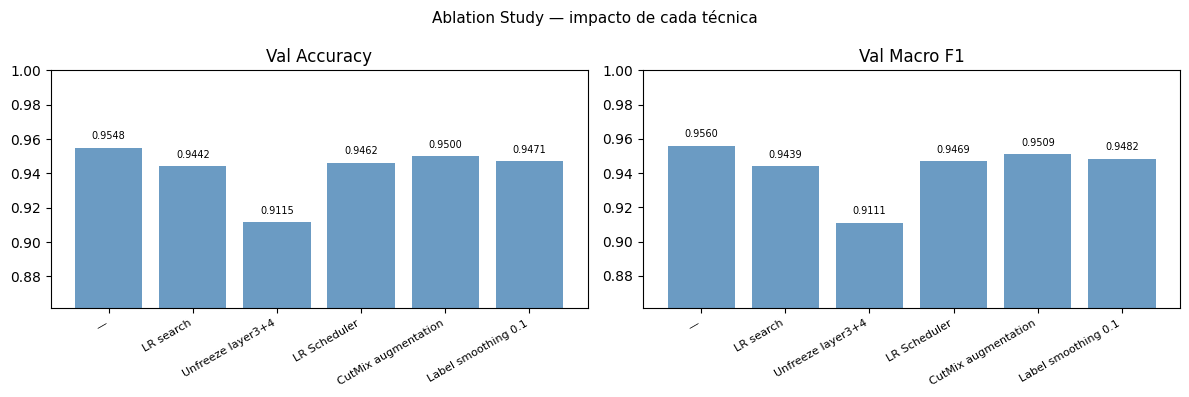

In [ ]:
# Carregar resultado da fase 1 (preenche com os valores reais)
PHASE1_BEST_ACC = 0.9548  # <-- preenche com o melhor val acc da fase 1
PHASE1_BEST_F1  = 0.9560   # <-- preenche com o melhor val F1 da fase 1

ablation_rows = [
    {"Configuração": "Fase 1 — melhor baseline",
     "Val Accuracy": PHASE1_BEST_ACC, "Val Macro F1": PHASE1_BEST_F1,
     "Técnica adicionada": "—"},
    {"Configuração": f"+ Melhor LR ({BEST_LR})",
     "Val Accuracy": lr_df.iloc[0]["Val Accuracy"],
     "Val Macro F1": lr_df.iloc[0]["Val Macro F1"],
     "Técnica adicionada": "LR search"},
    {"Configuração": "+ Fine-tuning gradual",
     "Val Accuracy": round(ft_acc, 4), "Val Macro F1": round(ft_f1, 4),
     "Técnica adicionada": "Unfreeze layer3+4"},
    {"Configuração": "+ CosineAnnealingLR",
     "Val Accuracy": round(sched_acc, 4), "Val Macro F1": round(sched_f1, 4),
     "Técnica adicionada": "LR Scheduler"},
    {"Configuração": "+ CutMix",
     "Val Accuracy": round(cm_acc, 4), "Val Macro F1": round(cm_f1, 4),
     "Técnica adicionada": "CutMix augmentation"},
    {"Configuração": "+ Label Smoothing",
     "Val Accuracy": round(ls_acc, 4), "Val Macro F1": round(ls_f1, 4),
     "Técnica adicionada": "Label smoothing 0.1"},
]

ablation_df = pd.DataFrame(ablation_rows)
print(ablation_df.to_string(index=False))
ablation_df.to_csv("../outputs/results/ablation_study.csv", index=False)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["Val Accuracy", "Val Macro F1"]):
    ax.bar(range(len(ablation_df)), ablation_df[metric], color="steelblue", alpha=0.8)
    ax.set_xticks(range(len(ablation_df)))
    ax.set_xticklabels([r["Técnica adicionada"] for r in ablation_rows], rotation=30, ha="right", fontsize=8)
    ax.set_title(metric)
    ax.set_ylim(max(0, ablation_df[metric].min() - 0.05), 1.0)
    for i, v in enumerate(ablation_df[metric]):
        ax.text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=7)
plt.suptitle("Ablation Study — impacto de cada técnica", fontsize=11)
plt.tight_layout()
plt.savefig("../outputs/figures/ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Passo 7 — TTA (Test-Time Augmentation) + Submission Final
Na inferência fazemos múltiplos crops/flips de cada imagem e calculamos a média
das probabilidades. Melhora a generalização sem re-treinar.

In [27]:
import torchvision.transforms as T

# Selecciona o melhor modelo da fase 2
best_phase2_acc = max(ls_acc, cm_acc, sched_acc, ft_acc)
if best_phase2_acc == ls_acc:
    best_model_p2 = model_ls
    print("Melhor modelo fase 2: Label Smoothing")
elif best_phase2_acc == cm_acc:
    best_model_p2 = model_cm
    print("Melhor modelo fase 2: CutMix")
elif best_phase2_acc == sched_acc:
    best_model_p2 = model_sched
    print("Melhor modelo fase 2: Scheduler")
else:
    best_model_p2 = model_ft
    print("Melhor modelo fase 2: Fine-tuning gradual")

print(f"Val Acc fase 2: {best_phase2_acc:.4f}")


# ── Transforms TTA ────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

tta_transforms = [
    T.Compose([T.Resize((224, 224)), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize((224, 224)), T.RandomHorizontalFlip(p=1.0), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize((256, 256)), T.CenterCrop(224), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize((256, 256)), T.CenterCrop(224), T.RandomHorizontalFlip(p=1.0), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
]


SAMPLE_SUBMISSION_PATH = "/Users/ritapduarte/4ano/2semestre/ACA/submission.csv"  # ficheiro de exemplo do enunciado

def predict_tta(model, sample_submission_path, test_dir, transforms_list, device, batch_size=32):
    # Usa o submission de exemplo para garantir os 1300 filenames correctos
    sample_df = pd.read_csv(sample_submission_path)
    test_df   = pd.DataFrame({"filename": sample_df["filename"]})
    
    model.eval()
    all_probs     = None
    filenames_out = None

    for tfm in transforms_list:
        dataset = ButterflyDataset(test_df, test_dir, transform=tfm, is_test=True)
        loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

        probs_list, fnames_list = [], []
        with torch.no_grad():
            for images, fnames in loader:
                images = images.to(device)
                logits = model(images)
                probs  = torch.softmax(logits, dim=1).cpu().numpy()
                probs_list.append(probs)
                fnames_list.extend(fnames)

        probs_arr = np.vstack(probs_list)
        if all_probs is None:
            all_probs     = probs_arr
            filenames_out = fnames_list
        else:
            all_probs += probs_arr

    avg_probs   = all_probs / len(transforms_list)
    preds       = avg_probs.argmax(axis=1)
    labels_pred = [idx_to_class[p] for p in preds]
    return pd.DataFrame({"filename": filenames_out, "label": labels_pred})


print("\nA gerar submission com TTA...")
submission_tta = predict_tta(
    best_model_p2, SAMPLE_SUBMISSION_PATH, test_dir, tta_transforms, device
)
submission_tta.to_csv("../outputs/submissions/submission_resnet_phase2_tta.csv", index=False)
print(f"Linhas geradas: {len(submission_tta)}")  # deve ser 1300
submission_tta.head()

Melhor modelo fase 2: CutMix
Val Acc fase 2: 0.9500

A gerar submission com TTA...
Linhas geradas: 1300


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,APPOLLO
2,Image_2.jpg,ZEBRA LONG WING
3,Image_3.jpg,COMMON BANDED AWL
4,Image_4.jpg,PAPER KITE


In [28]:
# ── Guardar melhor modelo fase 2 ──────────────────────────────────────────────
torch.save(best_model_p2.state_dict(), "best_resnet_phase2.pth")
print("Melhor modelo fase 2 guardado em best_resnet_phase2.pth")

# Resumo final
print("\n" + "="*50)
print("RESUMO FINAL")
print("="*50)
print(f"Melhor modelo fase 1 — Val Acc: {PHASE1_BEST_ACC:.4f} | F1: {PHASE1_BEST_F1:.4f}")
print(f"Melhor modelo fase 2 — Val Acc: {best_phase2_acc:.4f}")
print(f"Ganho:  {best_phase2_acc - PHASE1_BEST_ACC:+.4f}")

Melhor modelo fase 2 guardado em best_resnet_phase2.pth

RESUMO FINAL
Melhor modelo fase 1 — Val Acc: 0.9548 | F1: 0.9560
Melhor modelo fase 2 — Val Acc: 0.9500
Ganho:  -0.0048


In [29]:
# Modelo final com tudo combinado
model_final = build_model(BEST_ARCH, NUM_CLASSES).to(device)
criterion   = get_criterion("CrossEntropyLoss", label_smoothing=0.1)
optimizer   = get_optimizer(BEST_OPTIMIZER, model_final.parameters(), lr=BEST_LR)
scheduler   = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

model_final, hist_final, _ = train_model(
    model_final, criterion, optimizer, train_loader, val_loader, device,
    num_epochs=20, patience=7, scheduler=scheduler,
    use_cutmix=True, cutmix_alpha=1.0,
    label="final_combinado"
)

_, final_acc, final_f1 = val_epoch(model_final, val_loader, criterion, device)
print(f"Modelo final combinado — Val Acc: {final_acc:.4f} | Val F1: {final_f1:.4f}")

  [final_combinado] Epoch 01/20 | Val acc 0.8308  F1 0.8231  Loss 1.5496
  [final_combinado] Epoch 02/20 | Val acc 0.8981  F1 0.8978  Loss 1.1888
  [final_combinado] Epoch 03/20 | Val acc 0.9221  F1 0.9221  Loss 1.0963
  [final_combinado] Epoch 04/20 | Val acc 0.9317  F1 0.9313  Loss 1.0624
  [final_combinado] Epoch 05/20 | Val acc 0.9231  F1 0.9231  Loss 1.0493
  [final_combinado] Epoch 06/20 | Val acc 0.9346  F1 0.9340  Loss 1.0459
  [final_combinado] Epoch 07/20 | Val acc 0.9346  F1 0.9348  Loss 1.0308
  [final_combinado] Epoch 08/20 | Val acc 0.9404  F1 0.9412  Loss 1.0137
  [final_combinado] Epoch 09/20 | Val acc 0.9413  F1 0.9414  Loss 1.0034
  [final_combinado] Epoch 10/20 | Val acc 0.9462  F1 0.9476  Loss 1.0110
  [final_combinado] Epoch 11/20 | Val acc 0.9413  F1 0.9423  Loss 1.0223
  [final_combinado] Epoch 12/20 | Val acc 0.9481  F1 0.9491  Loss 0.9933
  [final_combinado] Epoch 13/20 | Val acc 0.9481  F1 0.9492  Loss 0.9874
  [final_combinado] Epoch 14/20 | Val acc 0.9510  F

In [31]:
# ── Submission do modelo final combinado ──────────────────────────────────────
sample_submission = pd.read_csv("/Users/ritapduarte/4ano/2semestre/ACA/submission.csv")
test_df_final = pd.DataFrame({"filename": sample_submission["filename"]})

test_dataset_final = ButterflyDataset(test_df_final, test_dir, transform=test_transform, is_test=True)
test_loader_final  = DataLoader(test_dataset_final, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model_final.eval()
filenames_list, predictions = [], []

with torch.no_grad():
    for images, fnames in test_loader_final:
        images = images.to(device)
        preds  = model_final(images).argmax(dim=1).cpu().numpy()
        filenames_list.extend(fnames)
        predictions.extend([idx_to_class[p] for p in preds])

submission_final = pd.DataFrame({
    "filename": filenames_list,
    "label":    predictions,
})
submission_final.to_csv("../outputs/submissions/submission_final_combinado.csv", index=False)
print(f"Submission guardada ({len(submission_final)} linhas)")
submission_final.head()

Submission guardada (1300 linhas)


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,APPOLLO
2,Image_2.jpg,ZEBRA LONG WING
3,Image_3.jpg,COMMON BANDED AWL
4,Image_4.jpg,PAPER KITE
